# ESM2 — Protein Language Model

Visualization notebook: training curves, data statistics, attention heatmaps, masked prediction.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path(".").resolve()))

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
from model import (
    AA_VOCAB,
    CLS_IDX,
    EOS_IDX,
    ESM2,
    MASK_IDX,
    PAD_IDX,
    AA_TO_IDX,
    IDX_TO_AA,
    mask_tokens,
)

model = ESM2(num_layers=12, hidden_dim=512, num_heads=16, ffn_dim=2048, dropout=0.0).to(device)
ckpt = torch.load("checkpoint.pt", map_location=device, weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"ESM2 loaded: {model.count_parameters():,} parameters")

ESM2 loaded: 50,407,449 parameters


## 1. Training Curves

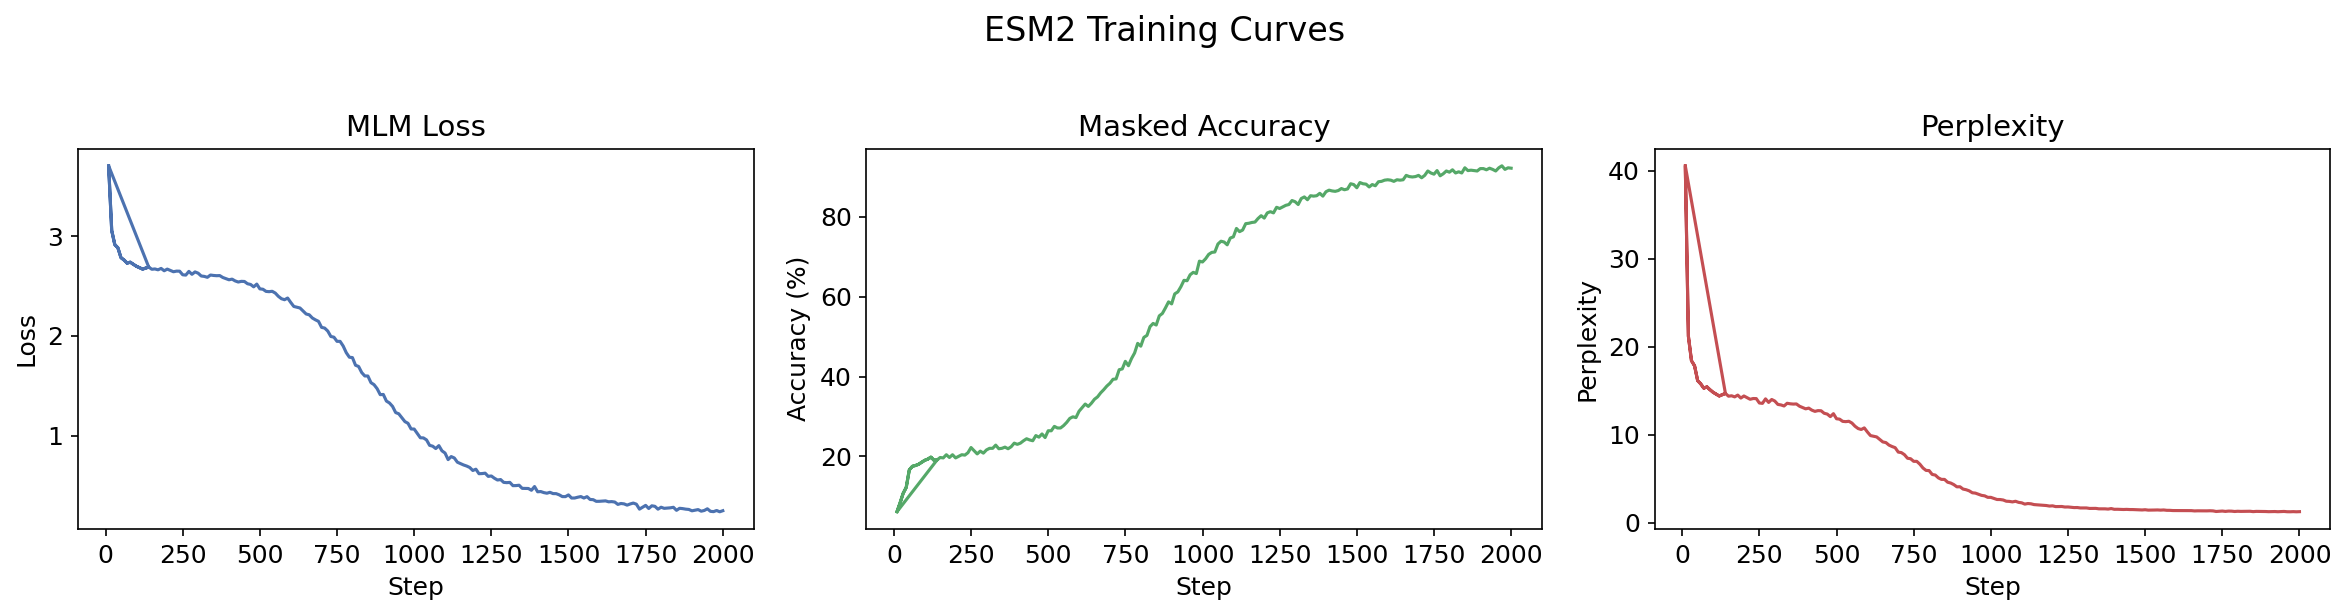

In [3]:
def parse_log(log_path, fields):
    """Parse training log. Returns dict of field_name -> list of floats."""
    data = {f: [] for f in fields}
    pattern = {f: re.compile(rf"{f}=([0-9eE.+-]+)") for f in fields}
    with open(log_path) as fh:
        for line in fh:
            if "step=" not in line:
                continue
            for f in fields:
                m = pattern[f].search(line)
                if m:
                    data[f].append(float(m.group(1)))
    return {f: np.array(v) for f, v in data.items()}


log = parse_log("../outputs/esm2/train.log", ["step", "loss", "acc"])
ppl = np.exp(log["loss"])  # perplexity = exp(loss)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(log["step"], log["loss"], color="#4C72B0")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("MLM Loss")

axes[1].plot(log["step"], log["acc"] * 100, color="#55A868")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Masked Accuracy")

axes[2].plot(log["step"], ppl, color="#C44E52")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Perplexity")
axes[2].set_title("Perplexity")

fig.suptitle("ESM2 Training Curves", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## 2. Training Data

Loaded 50000 sequences


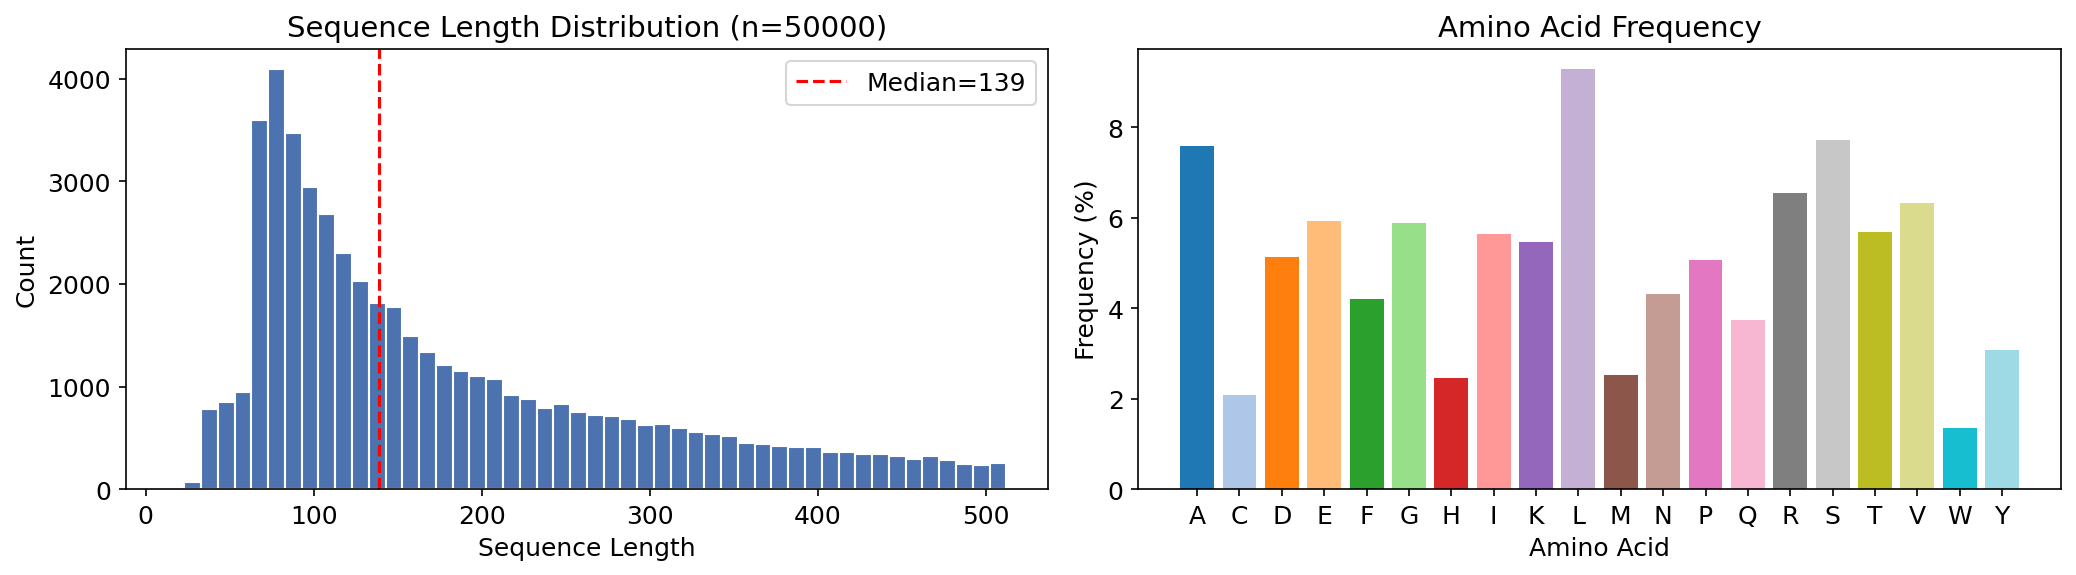

In [4]:
# Load FASTA sequences
fasta_path = Path("../data/sequences/uniref50_subset.fasta")
sequences = []
current_seq = []
with open(fasta_path) as f:
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if current_seq:
                sequences.append("".join(current_seq))
            current_seq = []
        elif line:
            current_seq.append(line)
    if current_seq:
        sequences.append("".join(current_seq))

print(f"Loaded {len(sequences)} sequences")

lengths = [len(s) for s in sequences]
aa_counts = {aa: 0 for aa in AA_VOCAB}
for seq in sequences:
    for aa in seq:
        if aa in aa_counts:
            aa_counts[aa] += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(lengths, bins=50, color="#4C72B0", edgecolor="white")
ax1.set_xlabel("Sequence Length")
ax1.set_ylabel("Count")
ax1.set_title(f"Sequence Length Distribution (n={len(sequences)})")
ax1.axvline(np.median(lengths), color="red", linestyle="--", label=f"Median={np.median(lengths):.0f}")
ax1.legend()

total = sum(aa_counts.values())
freqs = [aa_counts[aa] / total * 100 for aa in AA_VOCAB]
colors = plt.cm.tab20(np.linspace(0, 1, 20))
ax2.bar(AA_VOCAB, freqs, color=colors)
ax2.set_xlabel("Amino Acid")
ax2.set_ylabel("Frequency (%)")
ax2.set_title("Amino Acid Frequency")

fig.tight_layout()
plt.show()

## 3. Attention Heatmaps

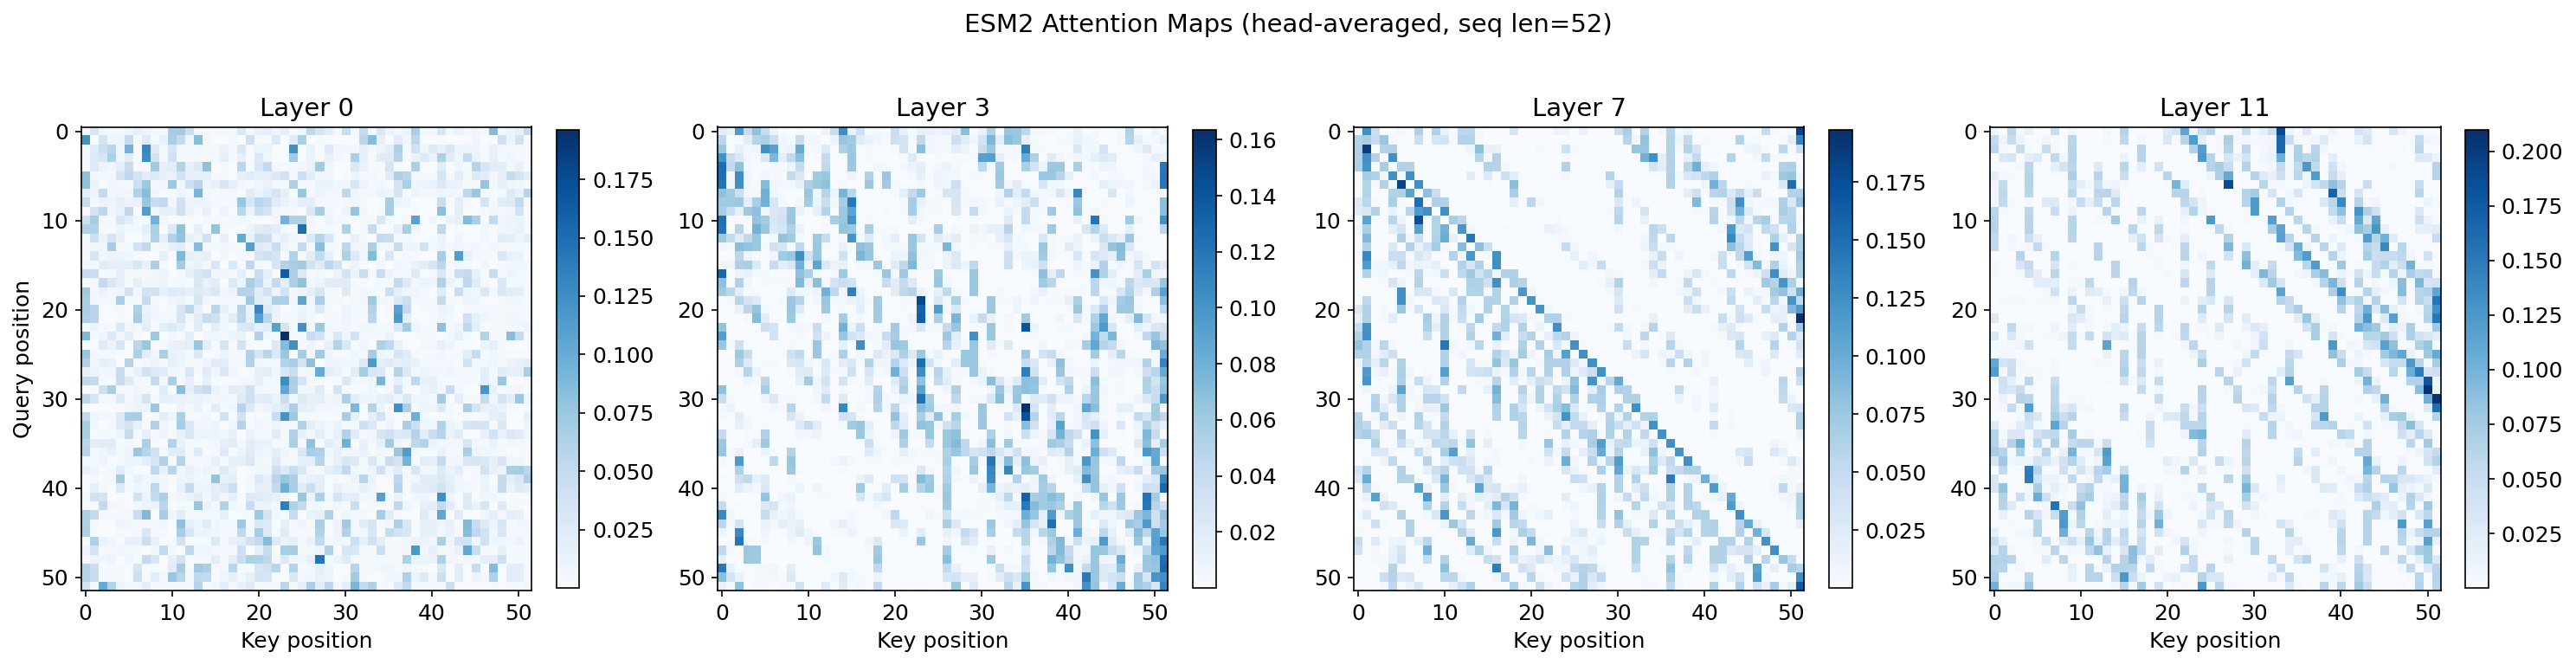

In [5]:
# Run a short sequence through the model
test_seq = sequences[0][:50]  # first 50 residues of first sequence
tokens = [CLS_IDX] + [AA_TO_IDX.get(aa, 24) for aa in test_seq] + [EOS_IDX]
tokens_t = torch.tensor([tokens], dtype=torch.long, device=device)
mask_t = torch.ones(1, len(tokens), dtype=torch.bool, device=device)

with torch.no_grad():
    out = model(tokens_t, mask_t)
attn = out["attention_weights"].cpu().numpy()  # [num_layers, 1, num_heads, L, L]
L = len(tokens)

# Show attention from layers 0, 3, 7, 11 (first, early-mid, late-mid, last)
layer_indices = [0, 3, 7, 11]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, li in zip(axes, layer_indices):
    # Average over heads
    avg_attn = attn[li, 0].mean(axis=0)  # [L, L]
    im = ax.imshow(avg_attn, cmap="Blues", aspect="auto")
    ax.set_title(f"Layer {li}")
    ax.set_xlabel("Key position")
    if li == layer_indices[0]:
        ax.set_ylabel("Query position")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(f"ESM2 Attention Maps (head-averaged, seq len={L})", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

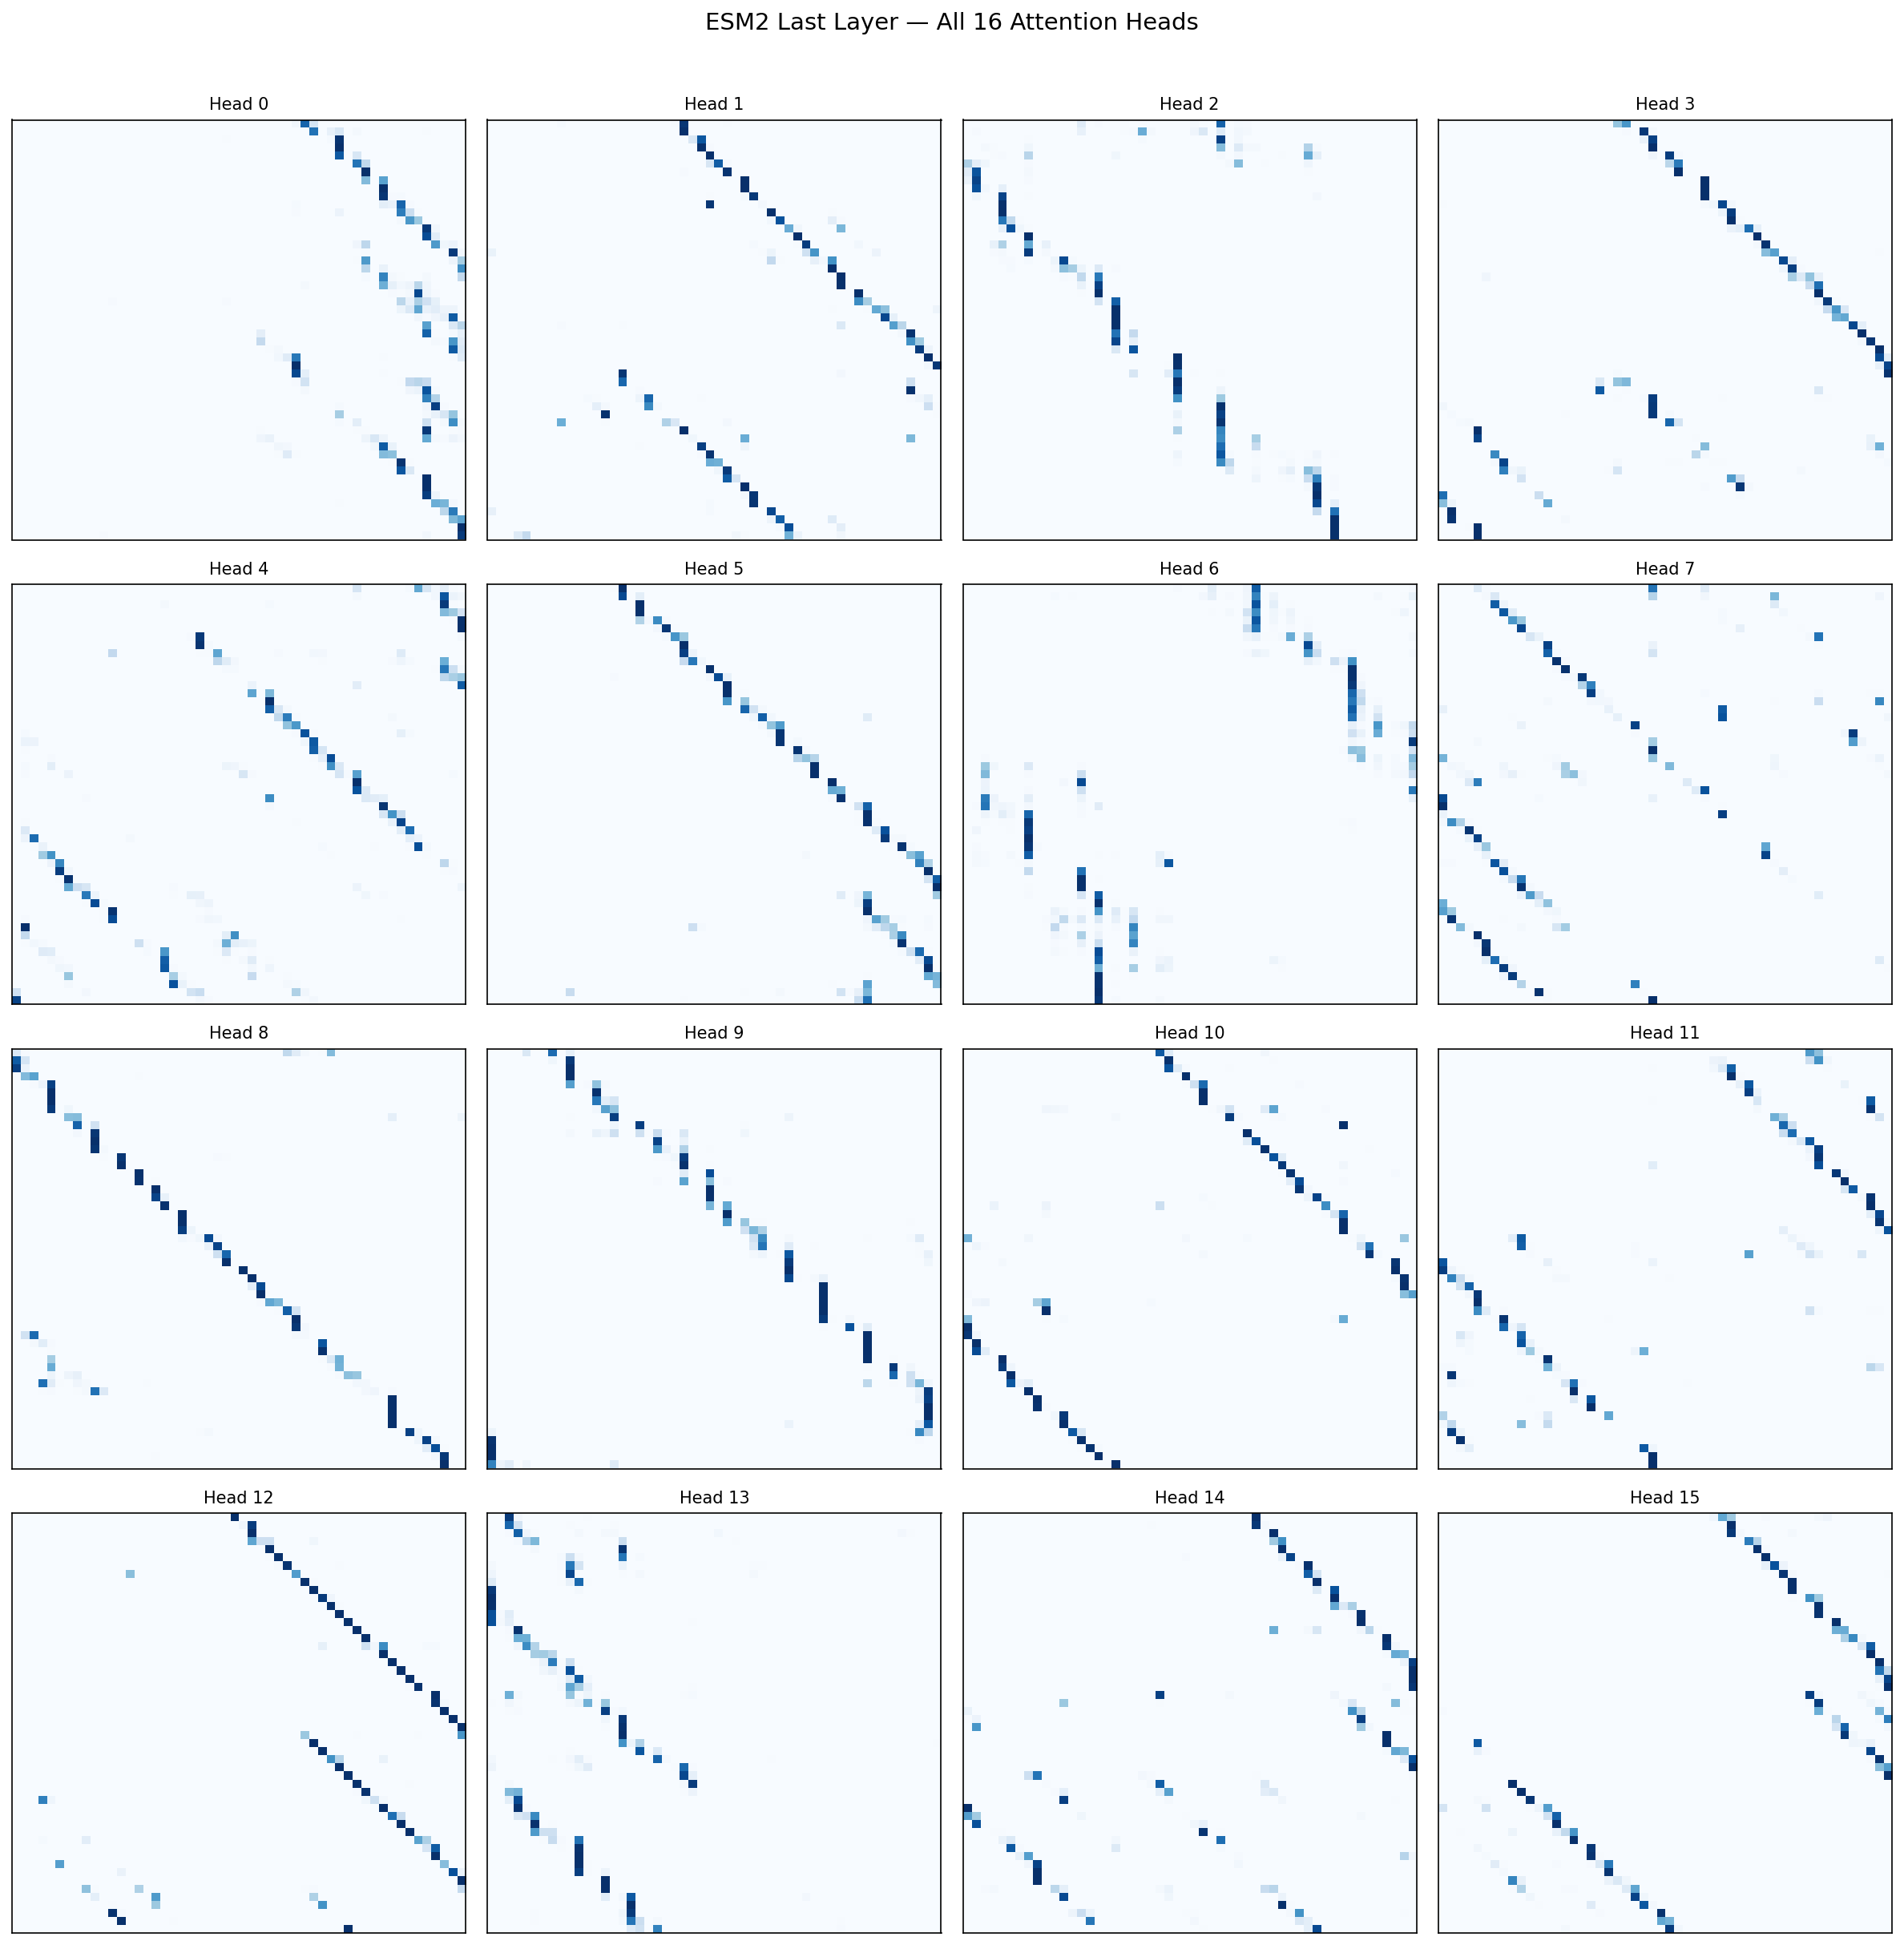

In [6]:
# Per-head attention in last layer
last_layer_attn = attn[-1, 0]  # [num_heads, L, L]
n_heads = last_layer_attn.shape[0]
cols = 4
rows = (n_heads + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
for i, ax in enumerate(axes.flat):
    if i < n_heads:
        ax.imshow(last_layer_attn[i], cmap="Blues", aspect="auto")
        ax.set_title(f"Head {i}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"ESM2 Last Layer — All {n_heads} Attention Heads", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4. Masked Prediction

In [7]:
# Mask specific positions and show top-k predictions
test_seq_full = sequences[0][:80]
tokens_orig = [CLS_IDX] + [AA_TO_IDX.get(aa, 24) for aa in test_seq_full] + [EOS_IDX]
tokens_masked = list(tokens_orig)

# Mask positions 10, 25, 40, 55, 70 (within the sequence, offset by 1 for CLS)
mask_positions = [11, 26, 41, 56, 71]
for pos in mask_positions:
    tokens_masked[pos] = MASK_IDX

tokens_t = torch.tensor([tokens_masked], dtype=torch.long, device=device)
mask_t = torch.ones(1, len(tokens_masked), dtype=torch.bool, device=device)

with torch.no_grad():
    out = model(tokens_t, mask_t)
logits = out["logits"][0].cpu()  # [L, vocab_size]

print("Masked Prediction Results")
print("=" * 60)
k = 5
results = []
for pos in mask_positions:
    true_aa = test_seq_full[pos - 1]  # offset for CLS
    probs = torch.softmax(logits[pos, :20], dim=-1)  # only AA tokens
    topk_probs, topk_idx = probs.topk(k)
    topk_aas = [AA_VOCAB[i] for i in topk_idx]
    pred_str = "  ".join(f"{aa}({p:.2f})" for aa, p in zip(topk_aas, topk_probs))
    match = "correct" if topk_aas[0] == true_aa else "wrong"
    print(f"  Position {pos - 1:>3d}: true={true_aa}  top-{k}: {pred_str}  [{match}]")
    results.append((pos - 1, true_aa, topk_aas, topk_probs.numpy()))

Masked Prediction Results
  Position  10: true=A  top-5: F(0.86)  A(0.10)  Y(0.02)  V(0.01)  T(0.01)  [wrong]
  Position  25: true=S  top-5: P(0.77)  D(0.18)  T(0.05)  Q(0.00)  A(0.00)  [wrong]
  Position  40: true=A  top-5: D(0.40)  K(0.22)  N(0.15)  T(0.04)  Q(0.03)  [wrong]
  Position  55: true=P  top-5: E(0.40)  L(0.33)  V(0.08)  H(0.07)  S(0.03)  [wrong]
  Position  70: true=S  top-5: D(0.40)  V(0.39)  E(0.18)  Q(0.01)  R(0.00)  [wrong]


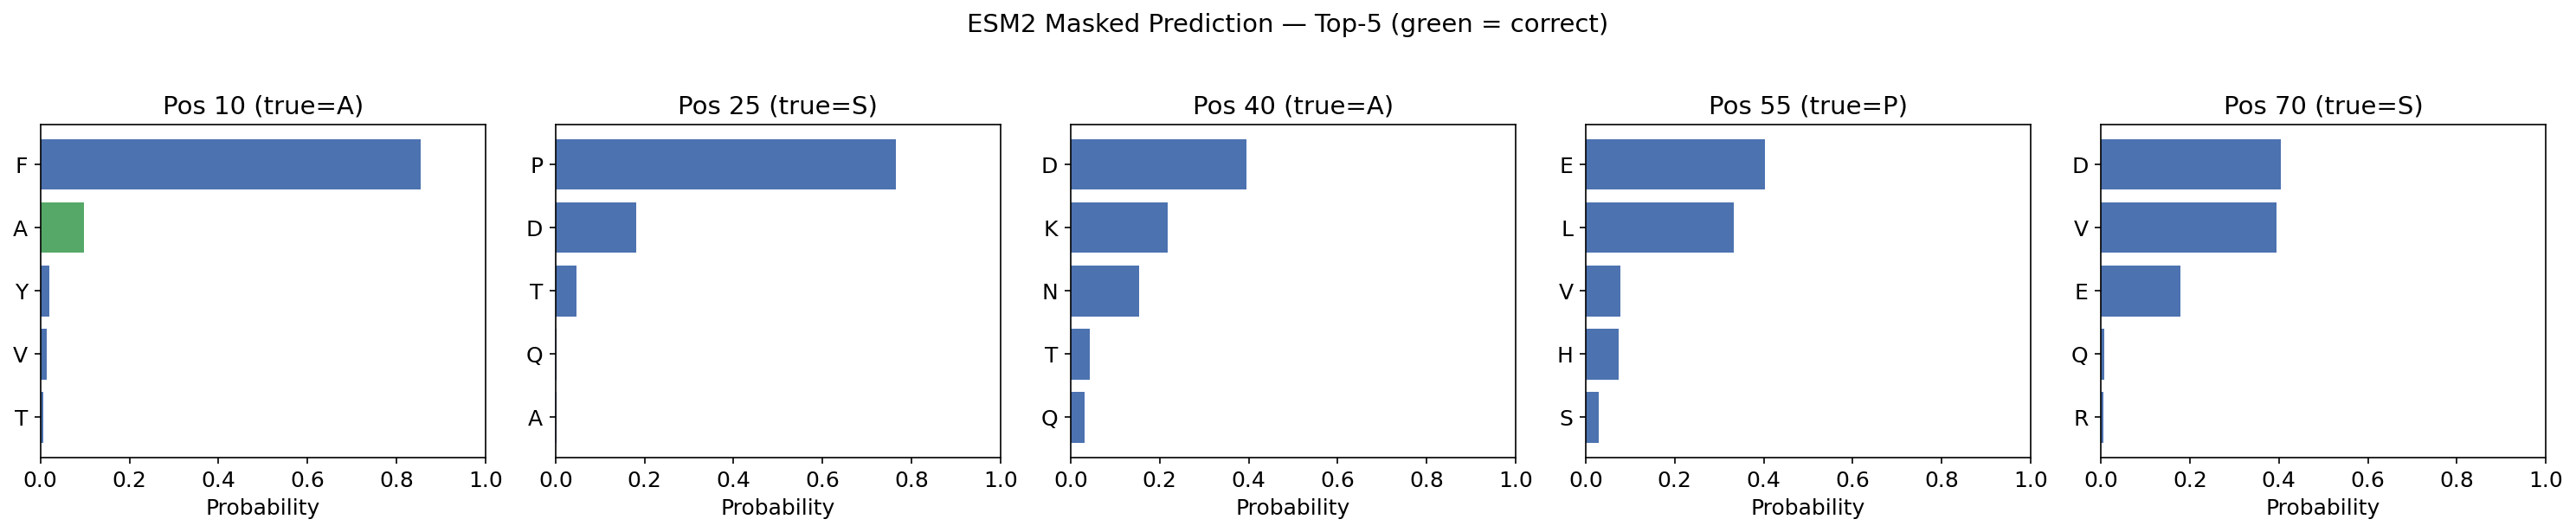

In [8]:
# Visualize masked prediction as bar charts
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))

for ax, (pos, true_aa, topk_aas, topk_probs) in zip(axes, results):
    bar_colors = ["#55A868" if aa == true_aa else "#4C72B0" for aa in topk_aas]
    ax.barh(range(k - 1, -1, -1), topk_probs, color=bar_colors)
    ax.set_yticks(range(k - 1, -1, -1))
    ax.set_yticklabels(topk_aas)
    ax.set_xlabel("Probability")
    ax.set_title(f"Pos {pos} (true={true_aa})")
    ax.set_xlim(0, 1)

fig.suptitle("ESM2 Masked Prediction — Top-5 (green = correct)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()